<a href="https://colab.research.google.com/github/NikitaIvagin/ml-portfolio/blob/main/time_series/apple_stock_forecast/Apple_stock_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd

# Построение моделей нейронных сетей
from keras.models import Sequential, Model

# Слои
from keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization
from keras.layers import Flatten, Conv1D, Conv2D, LSTM, GlobalMaxPooling1D
from keras.layers import MaxPooling1D, RepeatVector
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Оптимизаторы
from keras.optimizers import Adam

# Генератор выборки временных рядов
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормировка
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Отрисовка графиков
import matplotlib.pyplot as plt
%matplotlib inline

# Назначение размера и стиля графиков по умолчанию
from pylab import rcParams
plt.style.use('ggplot')
rcParams['figure.figsize'] = (12, 5)

# Отключение лишних предупреждений
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# импортируем файл с данными о котировках акций Apple
!wget https://storage.yandexcloud.net/academy.ai/AAPL.csv

# Загрузим только необходимые колонки usecols, укажем, что колонку Date необходимо преобразовать в формат DateTime (parse_dates) и сделать индексом index_col
price = pd.read_csv("./AAPL.csv", index_col='Date', usecols = ['Adj Close', 'Date'], parse_dates=['Date'])
price.head()

--2026-01-14 15:43:08--  https://storage.yandexcloud.net/academy.ai/AAPL.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 186539 (182K) [text/csv]
Saving to: ‘AAPL.csv.2’

AAPL.csv.2          100%[===================>] 182.17K   330KB/s    in 0.6s    

2026-01-14 15:43:09 (330 KB/s) - ‘AAPL.csv.2’ saved [186539/186539]



,Adj Close
Date,
2014-01-02,17.296652
2014-01-03,16.916719
2014-01-06,17.008968
2014-01-07,16.887323
2014-01-08,16.994270


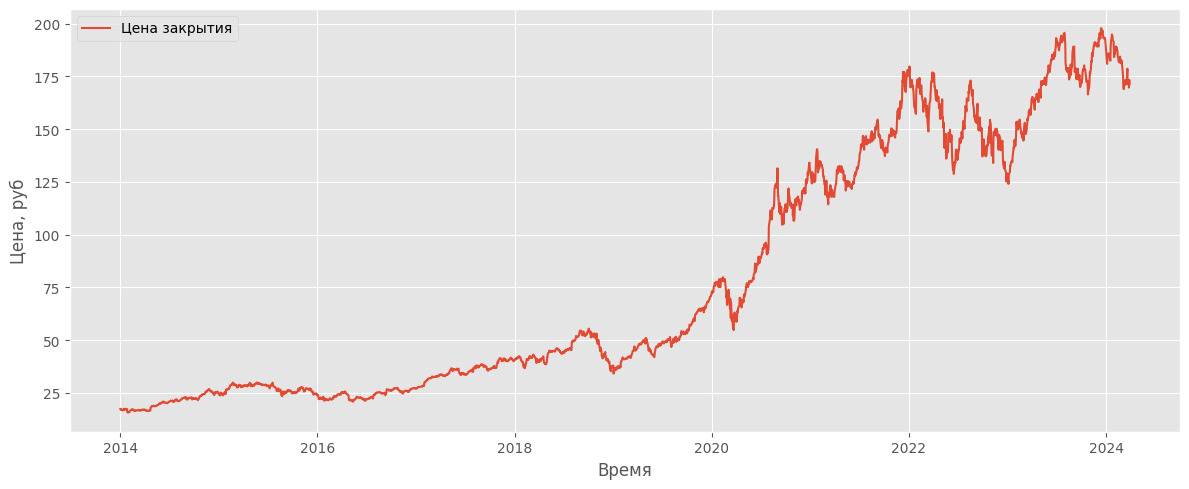

In [ ]:
# Задание полотна для графиков - два подграфика один под другим с общей осью x
fig, ax = plt.subplots(figsize=(12, 5), sharex=True)


# Отрисовка одного канала данных
# От начальной точки start длиной length
ax.plot(price.index, price['Adj Close'], label='Цена закрытия')

ax.set_ylabel('Цена, руб')
ax.legend()

plt.xlabel('Время')
# Регулировка пределов оси x
# plt.xlim(0, length)
# Указание расположить подграфики плотнее друг к другу
plt.tight_layout()
# Фиксация графика
plt.show()

In [ ]:
# Проведем дифференцирование для избавления от тренда
prices = np.asarray(price['Adj Close'])
prices = np.diff(prices)
price = price.iloc[1:]
price['Dif'] = prices
df = price.drop('Adj Close', axis=1)
price.drop('Dif', inplace=True, axis=1)

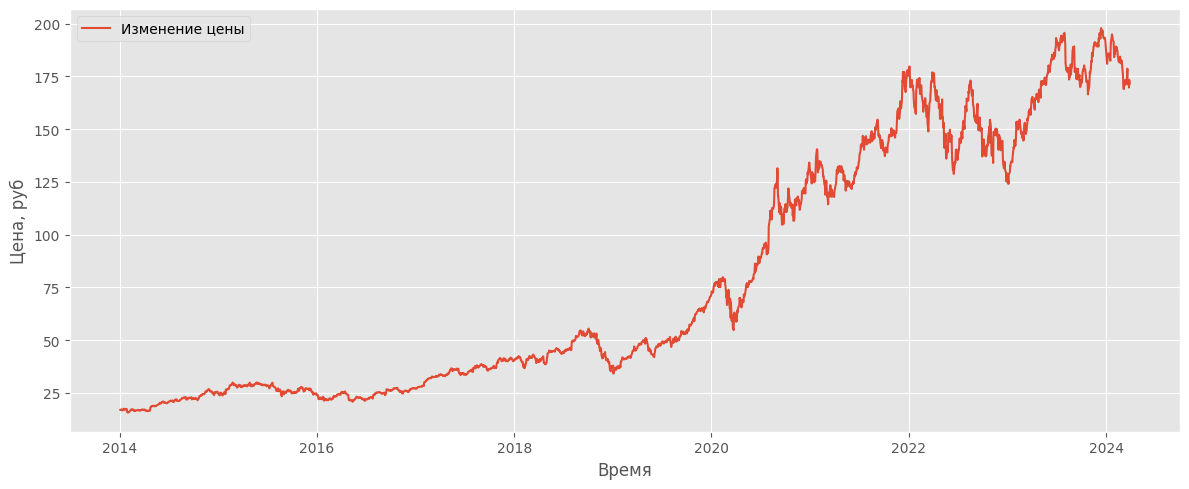

In [ ]:
# Задание полотна для графиков - два подграфика один под другим с общей осью x
fig, ax = plt.subplots(figsize=(12, 5), sharex=True)


# Отрисовка одного канала данных
# От начальной точки start длиной length
ax.plot(price.index, price['Adj Close'], label='Изменение цены')

ax.set_ylabel('Цена, руб')
ax.legend()

plt.xlabel('Время')
# Регулировка пределов оси x
# plt.xlim(0, length)
# Указание расположить подграфики плотнее друг к другу
plt.tight_layout()
# Фиксация графика
plt.show()

In [ ]:
train_data = price[:'2023-01-10']
test_data = price['2023-01-20':]

In [ ]:
dates = price.index[price.index >= '2023-01-20']
dates = dates[:-10]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_data)
scaled_train_data = scaler.transform(train_data)
scaled_test_data = scaler.transform(test_data)

In [ ]:
# Проверка формы данных
print(f'Тренировочные данные: {scaled_train_data.shape}')
print(f'Тестовые данные: {scaled_test_data.shape}')

Тренировочные данные: (2271, 1)
Тестовые данные: (299, 1)


In [ ]:
n_input = 10
n_features = 1
BATCH_SIZE = 2 # Эксперименты показали, что уменьшение размера выборки ведет к увеличению точности

generator = TimeseriesGenerator(scaled_train_data, scaled_train_data, length=n_input, batch_size=BATCH_SIZE)
print(f'Форма обучающего пакета: {generator[0][0].shape}, y: {generator[0][1].shape}')

Форма обучающего пакета: (2, 10, 1), y: (2, 1)


In [ ]:
validator = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=BATCH_SIZE)
print(f'Форма валидационного пакета: {validator[0][0].shape}, y: {validator[0][1].shape}')

Форма валидационного пакета: (2, 10, 1), y: (2, 1)


In [ ]:
tester = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=scaled_test_data.shape[0])
x_test, y_test = tester[0]
print(f'Форма тестовой выборки: {x_test.shape}, y: {y_test.shape}')

Форма тестовой выборки: (289, 10, 1), y: (289, 1)


In [ ]:
# Объявление функции графика обучения
def history_plot(history, title):

    # Рисование графиков обучения
    fig = plt.figure(figsize=(14, 7))
    plt.plot(history.history['loss'], label='Ошибка на обучающем наборе')
    plt.plot(history.history['val_loss'], label='Ошибка на проверочном наборе')
    plt.title(f'{title}. График обучения')

    # Показываем только целые метки шкалы оси x
    fig.gca().xaxis.get_major_locator().set_params(integer=True)
    plt.xlabel('Эпоха обучения')
    plt.ylabel('Средняя ошибка')
    plt.legend()
    plt.show()

# Функция расчета корреляции для двух рядов
def correlate(a, b):
    return np.corrcoef(a, b)[0, 1]

# Функция визуализации результата предсказания сети и верных ответов

def show_predict(y_pred, y_true, dates, title=None):
    """
    y_pred: прогнозные значения
    y_true: истинные значения
    dates: массив дат (опционально)
    title: заголовок графика
    """
    plt.figure(figsize=(15, 6))

    plt.plot(dates, y_true, label='Базовый ряд')
    plt.plot(dates, y_pred, label='Прогнозный ряд')
    plt.xticks(rotation=45)

    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Функция расчета результата предсказания
def get_pred(model, # модель
             x_test, y_test, # тестовая выборка
             y_scaler): # масштабирующий объект для y

    # Вычисление и деномализация предсказания
    y_pred_unscaled = y_scaler.inverse_transform(model.predict(x_test, verbose=0))

    # Денормализация верных ответов
    y_test_unscaled = y_scaler.inverse_transform(y_test)

    # Возврат результата предсказания и верные ответы в исходном масштабе
    return y_pred_unscaled, y_test_unscaled



# Функция рисования корреляций прогнозного ряда и исходного со смещением
# break_step - ограничитель на число временных лагов

def show_corr(y_pred, y_true, title='', break_step=30):

    # выбираем наименьшее из длины y_len и break_step в качестве числа лагов для графика
    y_len = y_true.shape[0]
    steps = range(1, np.min([y_len+1, break_step+1]))

    # Вычисление коэффициентов корреляции базового ряда и предсказания с разным смещением
    cross_corr = [correlate(y_true[:-step, 0], y_pred[step:, 0]) for step in steps]

    # Вычисление коэффициентов автокорреляции базового ряда с разным смещением
    auto_corr = [correlate(y_true[:-step, 0], y_true[step:, 0]) for step in steps]

    plt.plot(steps, cross_corr, label=f'Прогноз')
    plt.plot(steps, auto_corr, label=f'Эталон')

    plt.title(title)

    # Назначение меток шкалы оси x
    plt.xticks(steps)
    plt.xlabel('Шаги смещения')
    plt.ylabel('Коэффициент корреляции')
    plt.legend()
    plt.show()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
]

In [ ]:
# Простая полносвязная сеть
model_dense = Sequential()
model_dense.add(Dense(64, input_shape=generator[0][0].shape[1:], activation='relu'))
model_dense.add(Dense(32))
model_dense.add(Flatten())
model_dense.add(Dense(n_features, activation='linear'))

model_dense.compile(optimizer='adam', loss='mse')
model_dense.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10, 64)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,529 (9.88 KB)

 Trainable params: 2,529 (9.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_dense.fit(generator,
                epochs=100,
                validation_data=validator,
                callbacks=callbacks)

Epoch 1/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0040 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 2/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.5130e-04 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 3/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.4799e-04 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 4/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 4.4206e-04 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 5/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.5184e-04 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 6/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.8829e-04 - val_loss: 3.8283e-04 - learning_rate: 0.0010
Epoch 7/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.9358e-04 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 8/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 3.8778e-04 - val_loss: 2.5008e-04 - learning_rate: 0.0010
Epoch 9/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - los

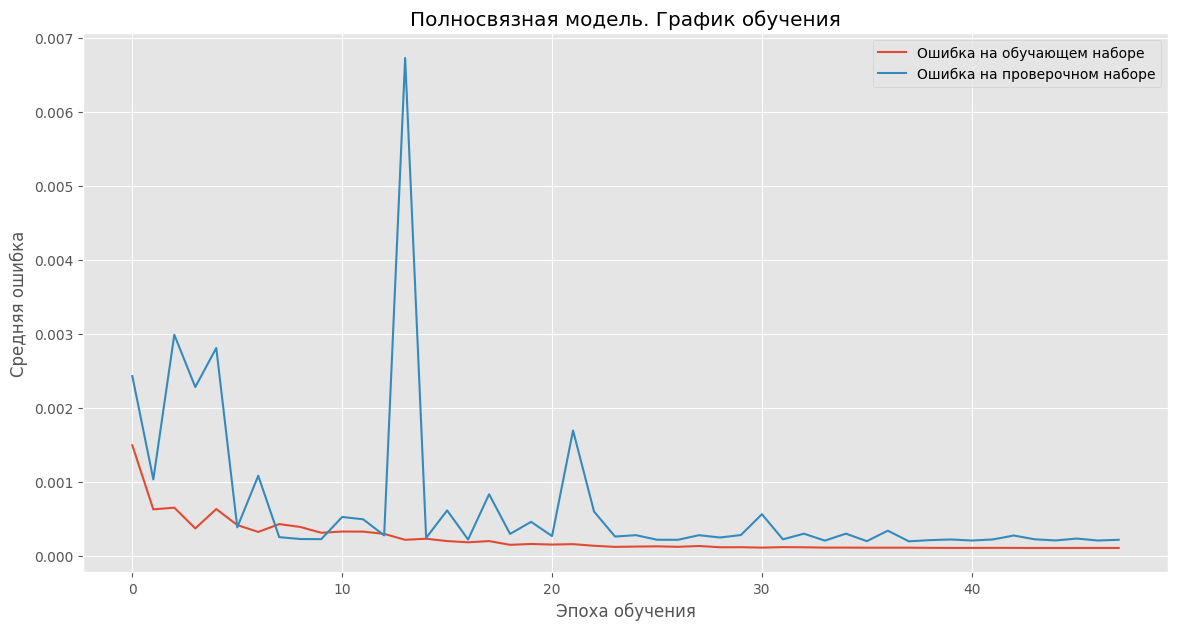

In [ ]:
history_plot(model_dense.history, 'Полносвязная модель')

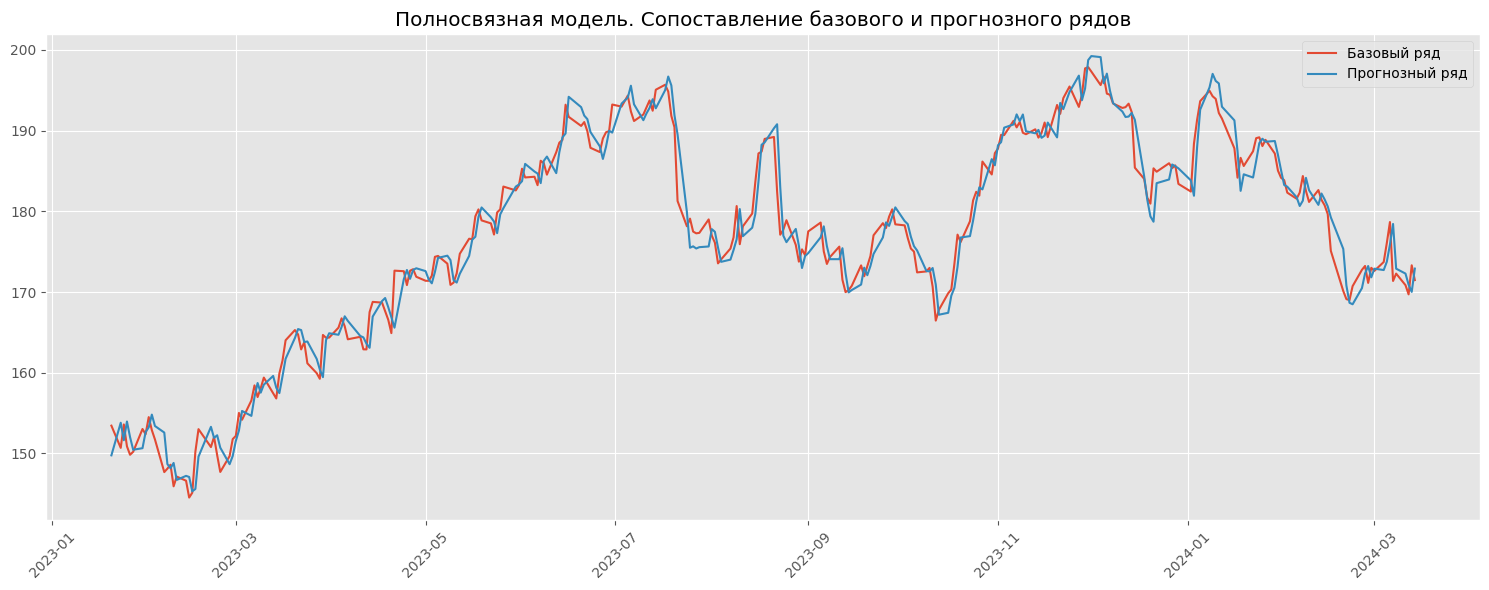

In [ ]:
# Получение денормализованного предсказания и данных базового ряда
y_pred, y_true = get_pred(model_dense, x_test, y_test, scaler)

# Отрисовка графика сопоставления базового и прогнозного рядов
show_predict(y_pred, y_true, dates, title=f'Полносвязная модель. Сопоставление базового и прогнозного рядов')

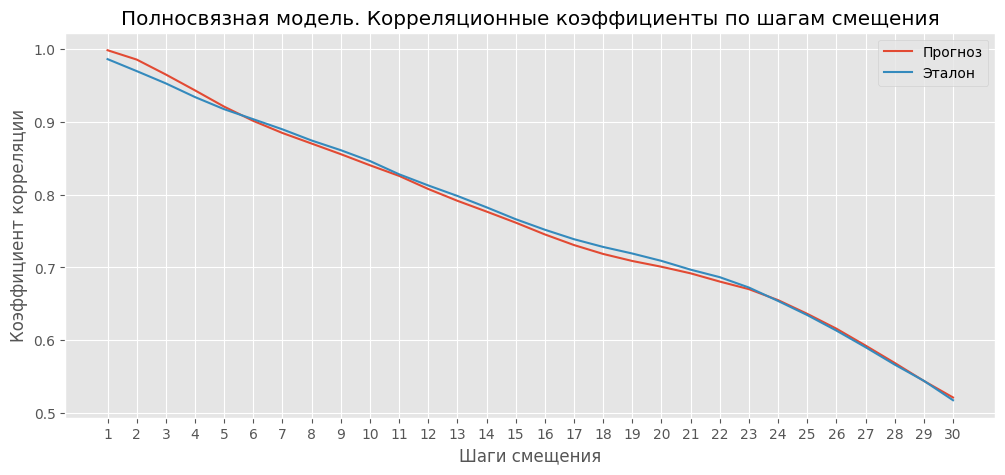

In [ ]:
# Отрисовка графика корреляционных коэффициентов до заданного максимума шагов смещения
show_corr(y_pred, y_true, title=f'Полносвязная модель. Корреляционные коэффициенты по шагам смещения')

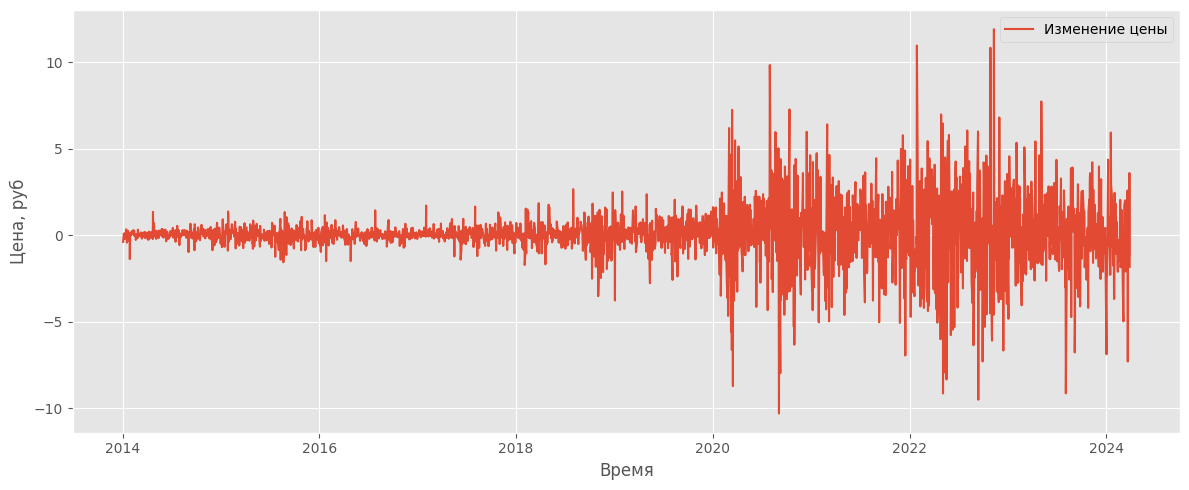

In [ ]:
# Повторим действия для дифференцированных данных
# Задание полотна для графиков - два подграфика один под другим с общей осью x
fig, ax = plt.subplots(figsize=(12, 5), sharex=True)


# Отрисовка одного канала данных
# От начальной точки start длиной length
ax.plot(df.index, df['Dif'], label='Изменение цены')

ax.set_ylabel('Цена, руб')
ax.legend()

plt.xlabel('Время')

# Указание расположить подграфики плотнее друг к другу
plt.tight_layout()
# Фиксация графика
plt.show()

In [ ]:
train_data = df[:'2023-01-10']
test_data = df['2023-01-20':]

scaler = MinMaxScaler()
scaler.fit(train_data)
scaled_train_data = scaler.transform(train_data)
scaled_test_data = scaler.transform(test_data)

generator = TimeseriesGenerator(scaled_train_data, scaled_train_data, length=n_input, batch_size=BATCH_SIZE)
validator = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=BATCH_SIZE)
tester = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=scaled_test_data.shape[0])
x_test, y_test = tester[0]

In [ ]:
model_new = Sequential()
model_new.add(Dense(64, input_shape=generator[0][0].shape[1:], activation='relu'))
model_new.add(Dense(32))
model_new.add(Flatten())
model_new.add(Dense(n_features, activation='linear'))

model_new.compile(optimizer='adam', loss='mse')
model_new.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10, 64)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,529 (9.88 KB)

 Trainable params: 2,529 (9.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_new.fit(generator,
                epochs=100,
                validation_data=validator,
                callbacks=callbacks)

Epoch 1/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0172 - val_loss: 0.0108 - learning_rate: 0.0010
Epoch 2/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0066 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 3/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0069 - val_loss: 0.0105 - learning_rate: 0.0010
Epoch 4/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0064 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 5/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0057 - val_loss: 0.0101 - learning_rate: 0.0010
Epoch 6/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0055 - val_loss: 0.0108 - learning_rate: 0.0010
Epoch 7/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0065 - val_loss: 0.0100 - learning_rate: 0.0010
Epoch 8/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0053 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 9/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0044 - val_loss: 0.0100 - learn

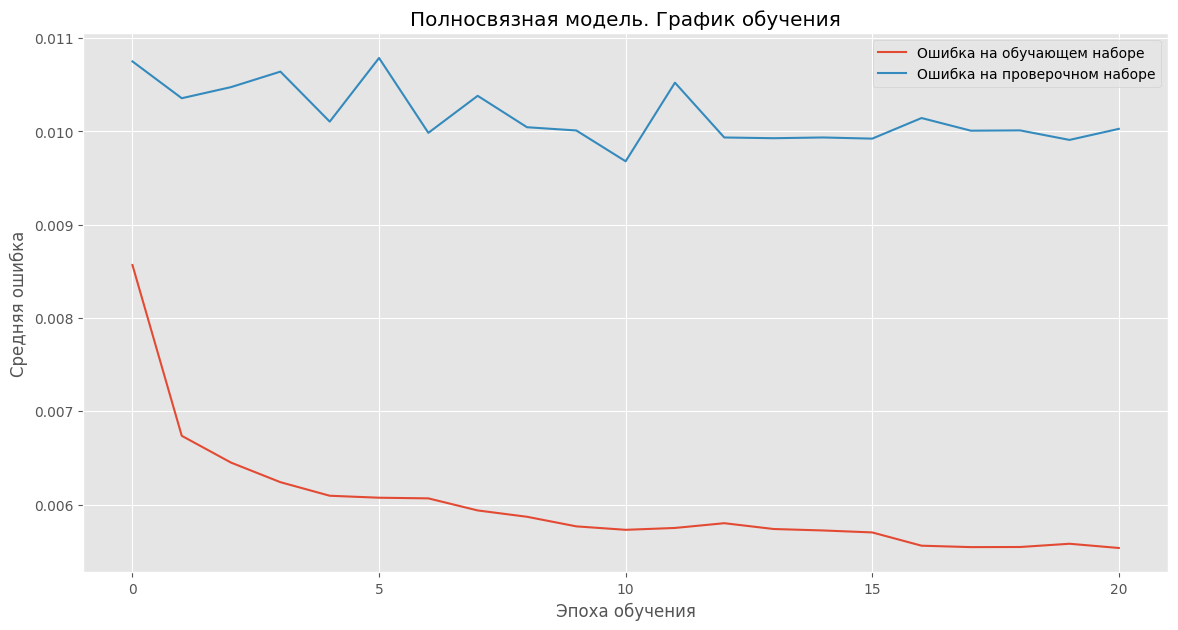

In [ ]:
history_plot(model_new.history, 'Полносвязная модель')